## Import Libraies and Modules

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

## Load Dataset

In [3]:
df = pd.read_csv('student_exam_scores.csv')
df

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,30.2
1,S002,1.3,8.6,60.7,55,25.0
2,S003,4.0,8.2,73.7,86,35.8
3,S004,3.5,4.8,95.1,66,34.0
4,S005,9.1,6.4,89.8,71,40.3
...,...,...,...,...,...,...
195,S196,10.5,5.4,94.0,87,42.7
196,S197,7.1,6.1,85.1,92,40.4
197,S198,1.6,6.9,63.8,76,28.2
198,S199,12.0,7.3,50.5,58,42.0


In [4]:
df.shape

(200, 6)

In [5]:
df.describe()

,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,6.325500,6.622000,74.830000,66.800000,33.955000
std,3.227317,1.497138,14.249905,15.663869,6.789548
min,1.000000,4.000000,50.300000,40.000000,17.100000
25%,3.500000,5.300000,62.200000,54.000000,29.500000
50%,6.150000,6.700000,75.250000,67.500000,34.050000
75%,9.000000,8.025000,87.425000,80.000000,38.750000
max,12.000000,9.000000,100.000000,95.000000,51.300000


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
print(df["exam_score"].min(), df["exam_score"].max())
print(df["previous_scores"].min(), df["previous_scores"].max())

17.1 51.3
40 95


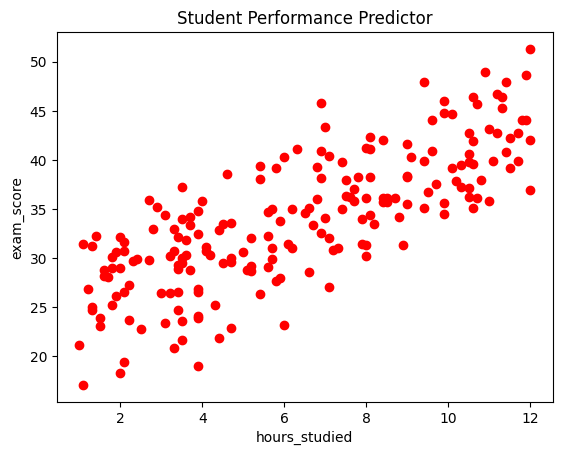

In [8]:
plt.scatter(df["hours_studied"],df["exam_score"],color='r')
plt.title("Student Performance Predictor")
plt.xlabel("hours_studied")
plt.ylabel("exam_score")
plt.show()

In [9]:
df.head()

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,30.2
1,S002,1.3,8.6,60.7,55,25.0
2,S003,4.0,8.2,73.7,86,35.8
3,S004,3.5,4.8,95.1,66,34.0
4,S005,9.1,6.4,89.8,71,40.3


In [10]:
df.ndim

2

In [11]:
X = df[["hours_studied", "sleep_hours", "attendance_percent", "previous_scores"]]
y = df["exam_score"]

In [12]:
X

,hours_studied,sleep_hours,attendance_percent,previous_scores
0,8.0,8.8,72.1,45
1,1.3,8.6,60.7,55
2,4.0,8.2,73.7,86
3,3.5,4.8,95.1,66
4,9.1,6.4,89.8,71
...,...,...,...,...
195,10.5,5.4,94.0,87
196,7.1,6.1,85.1,92
197,1.6,6.9,63.8,76
198,12.0,7.3,50.5,58


In [13]:
y

0      30.2
1      25.0
2      35.8
3      34.0
4      40.3
       ... 
195    42.7
196    40.4
197    28.2
198    42.0
199    37.8
Name: exam_score, Length: 200, dtype: float64

In [14]:
X.shape

(200, 4)

In [15]:
y.shape

(200,)

In [16]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [17]:
X_train

,hours_studied,sleep_hours,attendance_percent,previous_scores
79,3.7,7.0,88.3,84
197,1.6,6.9,63.8,76
38,10.5,7.0,72.8,59
24,11.5,4.3,74.7,77
122,9.6,8.1,82.5,90
...,...,...,...,...
106,2.2,5.5,56.8,80
14,8.1,8.8,60.0,90
92,9.7,7.2,71.8,68
179,6.1,8.2,86.6,52


In [18]:
X_test

,hours_studied,sleep_hours,attendance_percent,previous_scores
95,5.2,6.8,84.0,43
15,7.0,9.0,51.2,41
30,9.9,4.4,55.3,67
158,3.5,4.5,89.1,78
128,10.7,8.0,51.0,68
115,10.6,8.4,91.6,55
69,3.9,4.0,53.2,59
170,11.3,6.7,85.4,83
174,9.9,5.8,63.5,90
45,3.6,7.6,80.6,47


In [19]:
y_train

79     34.2
197    28.2
38     39.8
24     39.2
122    44.1
       ... 
106    23.7
14     41.1
92     37.5
179    31.4
102    35.7
Name: exam_score, Length: 160, dtype: float64

In [20]:
y_test

95     28.7
15     34.1
30     34.5
158    29.5
128    36.1
115    46.4
69     23.9
170    45.3
174    44.8
45     31.8
66     21.7
182    44.1
165    30.1
78     26.5
186    36.2
177    31.0
56     35.2
152    27.7
82     39.8
68     33.5
124    21.2
16     28.9
148    26.4
93     29.1
65     36.7
60     48.6
84     38.0
67     32.2
125    38.6
132    45.7
9      24.7
18     35.6
55     37.0
75     26.3
150    44.1
104    24.1
135    41.1
137    35.1
164    40.6
76     39.9
Name: exam_score, dtype: float64

In [21]:
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [22]:
model.coef_

array([1.54934126, 0.88415643, 0.10894946, 0.18303355])

In [23]:
model.intercept_

np.float64(-2.2049639058368484)

In [24]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [25]:
mean_absolute_error(y_train,y_pred_train)

2.2885816632317937

In [26]:
np.sqrt(mean_squared_error(y_train,y_pred_train))

np.float64(2.683137733254513)

In [27]:
mean_squared_error(y_train,y_pred_train)

7.199228095614165

In [28]:
r2_score(y_train,y_pred_train)

0.83642950148381

In [29]:
round(r2_score(y_train,y_pred_train),2)*100

84.0

In [30]:
round(r2_score(y_test,y_pred_test),2)*100

85.0

In [31]:

np.sqrt(mean_squared_error(y_test, y_pred_test))

np.float64(2.7859976074331207)

In [32]:
mean_absolute_error(y_test, y_pred_test)

2.3108582358958336

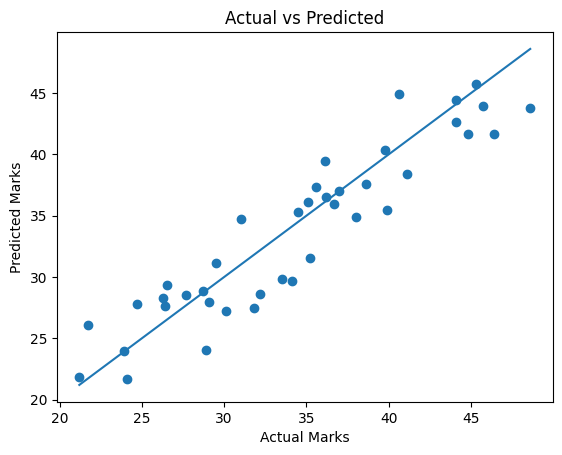

In [33]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_test)
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted")

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.show()

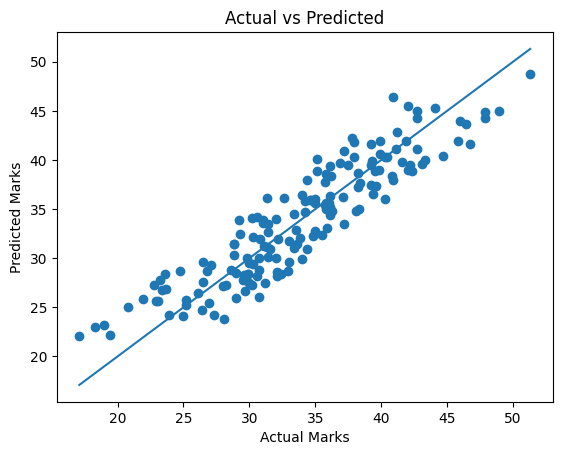

In [34]:
import matplotlib.pyplot as plt

plt.scatter(y_train, y_pred_train)
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted")

# Perfect prediction line
plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()])

plt.show()

In [35]:
with open("model.pkl", "wb") as file:
    pickle.dump(model, file)

In [36]:
print(df["exam_score"].min(), df["exam_score"].max())
print(df["previous_scores"].min(), df["previous_scores"].max())

17.1 51.3
40 95
